In [1]:
import gdsfactory as gf
from gsim.palace import DrivenSim

gf.gpdk.PDK.activate()

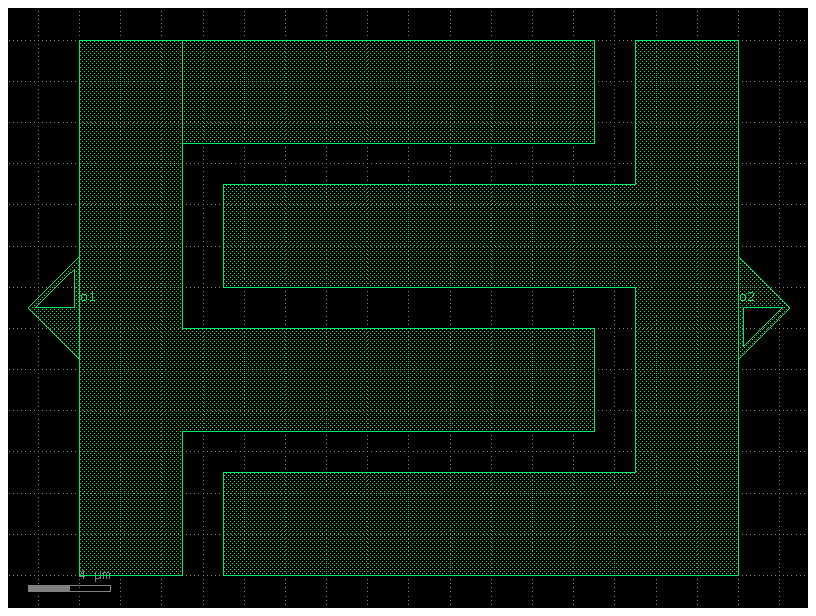

In [2]:
c=gf.components.interdigital_capacitor(
    fingers=4,
    finger_length=20,
    finger_gap=2,
    thickness=5,
    layer='M1'
    )

cc = c.copy() 
cc.flatten()

c.draw_ports()
c.plot()

We create a copy of the component and flatten it, since attempting to generate the mesh without applying `cc.flatten()` results in the following error:

```
Error   : Could not create line
Error   : Curve loop is not closed
---------------------------------------------------------------------------
Exception                                 Traceback (most recent call last)
/tmp/ipykernel_605040/3030631953.py in ?()
----> 1 sim.mesh(preset="graded",margin=5.0,refined_mesh_size=0.3)

~/projects/gsim/src/gsim/palace/driven.py in ?(self, preset, refined_mesh_size, max_mesh_size, margin, airbox_margin, fmax, planar_conductors, show_gui, model_name, verbose)
    662         # Extract ports
    663         palace_ports = extract_ports(component, stack)
    664 
    665         # Generate mesh (config is written separately by simulate() or write_config())
--> 666         return self._generate_mesh_internal(
    667             output_dir=output_dir,
    668             mesh_config=mesh_config,
    669             ports=palace_ports,

~/projects/gsim/src/gsim/palace/driven.py in ?(self, output_dir, mesh_config, ports, driven_config, model_name, verbose, write_config)
    461 
    462         if verbose:
    463             logger.info("Generating mesh in %s", output_dir)
    464 
--> 465         mesh_result = generate_mesh(
    466             component=component,
    467             stack=stack,
    468             ports=ports,

~/projects/gsim/src/gsim/palace/mesh/pipeline.py in ?(component, stack, ports, output_dir, config, model_name, driven_config, write_config, pec_blocks)
    205 
    206     output_dir = Path(output_dir)
    207 
    208     # Use new generator
--> 209     result = gen_mesh(
    210         component=component,
    211         stack=stack,
    212         ports=ports,

~/projects/gsim/src/gsim/palace/mesh/generator.py in ?(component, stack, ports, output_dir, model_name, refined_mesh_size, max_mesh_size, margin, air_margin, fmax, show_gui, driven_config, write_config, planar_conductors, refine_from_curves, pec_blocks, merge_via_distance)
    293             )
    294 
    295     finally:
    296         gmsh.clear()
--> 297         gmsh.finalize()
    298 
    299     # Build result (store groups for deferred config generation)
    300     result = MeshResult(

~/projects/gsim/src/gsim/palace/mesh/geometry.py in ?(kernel, geometry, stack, planar_conductors, merge_via_distance)
    275 
    276         # Create surfaces for all polygons on this layer
    277         surfaces = []
    278         for pts_x, pts_y, holes in polys:
--> 279             surfacetag = gmsh_utils.create_polygon_surface(
    280                 kernel, pts_x, pts_y, zmin, holes=holes
    281             )
    282             if surfacetag is not None:

~/projects/gsim/src/gsim/palace/mesh/gmsh_utils.py in ?(kernel, pts_x, pts_y, z, meshseed, holes)
    297     if len(linetaglist) < 3:
    298         return None
    299 
    300     # Create outer curve loop
--> 301     curvetag = kernel.addCurveLoop(linetaglist, tag=-1)
    302 
    303     # Create hole curve loops
    304     all_loops = [curvetag]

~/projects/gsim/.venv/lib/python3.12/site-packages/gmsh.py in ?(curveTags, tag)
   7232                 api_curveTags_, api_curveTags_n_,
   7233                 c_int(tag),
   7234                 byref(ierr))
   7235             if ierr.value != 0:
-> 7236                 raise Exception(logger.getLastError())
   7237             return api_result_

Exception: Curve loop is not closed
```

In [3]:
# Checking the port layers.
cc.ports

["Port(self.name='o1', self.width=5000, trans=r180 *1 0,13, layer=M1 (41/0), port_type=optical)", "Port(self.name='o2', self.width=5000, trans=r0 *1 32,13, layer=M1 (41/0), port_type=optical)"]

In [4]:
sim = DrivenSim()
sim.set_output_dir("runs/palace-sim-idc")
sim.set_geometry(cc)

sim.set_stack(
    substrate_thickness=2.0,
    air_above=5.0,
)

sim.add_port(name="o1", layer="metal1",geometry="inplane", excited=True)
sim.add_port(name="o2", layer="metal1", geometry="inplane", excited=False)

sim.set_driven(fmin=1e9, fmax=100e9, num_points=60)

print(sim.validate_config())

Validation: PASSED


In [5]:
# If there is an error, restart the kernel and run all cells again.
sim.mesh(preset="graded",margin=5.0,refined_mesh_size=0.3)

Mesh Summary
Dimensions: 42.0 x 36.0 x 12.6 µm
Nodes:      9,229
Elements:   67,430
Tetrahedra: 52,286
Edge length: 0.18 - 11.91 µm
Quality:    0.618 (min: 0.037)
SICN:       0.666 (all valid)
----------------------------------------
Volumes (3):
  - SiO2 [1]
  - passive [2]
  - air [3]
Surfaces (9):
  - metal1_xy [4]
  - metal1_z [5]
  - P1 [6]
  - P2 [7]
  - SiO2__None [8]
  - SiO2__passive [9]
  - passive__None [10]
  - air__passive [11]
  - air__None [12]
----------------------------------------
Mesh:   runs/palace-sim-idc/palace.msh

Occasionally, running the mesh produces the following error. This issue can be resolved by restarting the kernel and re-running all cells.

```
Warning : Fragments - BOPAlgo_AlertSolidBuilderUnusedFaces 
Error   : Invalid boundary mesh (overlapping facets) on surface 1 surface 57
---------------------------------------------------------------------------
Exception                                 Traceback (most recent call last)
/tmp/ipykernel_618723/3030631953.py in ?()
      1 # If there is an error, restart the kernel and run all cells again.
----> 2 sim.mesh(preset="graded",margin=5.0,refined_mesh_size=0.3)

~/projects/gsim/src/gsim/palace/driven.py in ?(self, preset, refined_mesh_size, max_mesh_size, margin, airbox_margin, fmax, planar_conductors, show_gui, model_name, verbose)
    662         # Extract ports
    663         palace_ports = extract_ports(component, stack)
    664 
    665         # Generate mesh (config is written separately by simulate() or write_config())
--> 666         return self._generate_mesh_internal(
    667             output_dir=output_dir,
    668             mesh_config=mesh_config,
    669             ports=palace_ports,

~/projects/gsim/src/gsim/palace/driven.py in ?(self, output_dir, mesh_config, ports, driven_config, model_name, verbose, write_config)
    461 
    462         if verbose:
    463             logger.info("Generating mesh in %s", output_dir)
    464 
--> 465         mesh_result = generate_mesh(
    466             component=component,
    467             stack=stack,
    468             ports=ports,

~/projects/gsim/src/gsim/palace/mesh/pipeline.py in ?(component, stack, ports, output_dir, config, model_name, driven_config, write_config, pec_blocks)
    205 
    206     output_dir = Path(output_dir)
    207 
    208     # Use new generator
--> 209     result = gen_mesh(
    210         component=component,
    211         stack=stack,
    212         ports=ports,

~/projects/gsim/src/gsim/palace/mesh/generator.py in ?(component, stack, ports, output_dir, model_name, refined_mesh_size, max_mesh_size, margin, air_margin, fmax, show_gui, driven_config, write_config, planar_conductors, refine_from_curves, pec_blocks, merge_via_distance)
    293             )
    294 
    295     finally:
    296         gmsh.clear()
--> 297         gmsh.finalize()
    298 
    299     # Build result (store groups for deferred config generation)
    300     result = MeshResult(

~/projects/gsim/.venv/lib/python3.12/site-packages/gmsh.py in ?(dim)
   2185             lib.gmshModelMeshGenerate(
   2186                 c_int(dim),
   2187                 byref(ierr))
   2188             if ierr.value != 0:
-> 2189                 raise Exception(logger.getLastError())

Exception: Invalid boundary mesh (overlapping facets) on surface 1 surface 57
```

2026-04-01 00:04:27.898 (   2.360s) [    7B8E9B278080]vtkXOpenGLRenderWindow.:1460  WARN| bad X server connection. DISPLAY=
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

2026-04-01 00:04:27.910 (   2.372s) [    7B8E9B278080]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

2026-04-01 00:04:27.926 (   2.388s) [    7B8E9B278080]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

2026-04-01 00:04:27.957 (   2.419s) [    7B8E9B278080]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initial

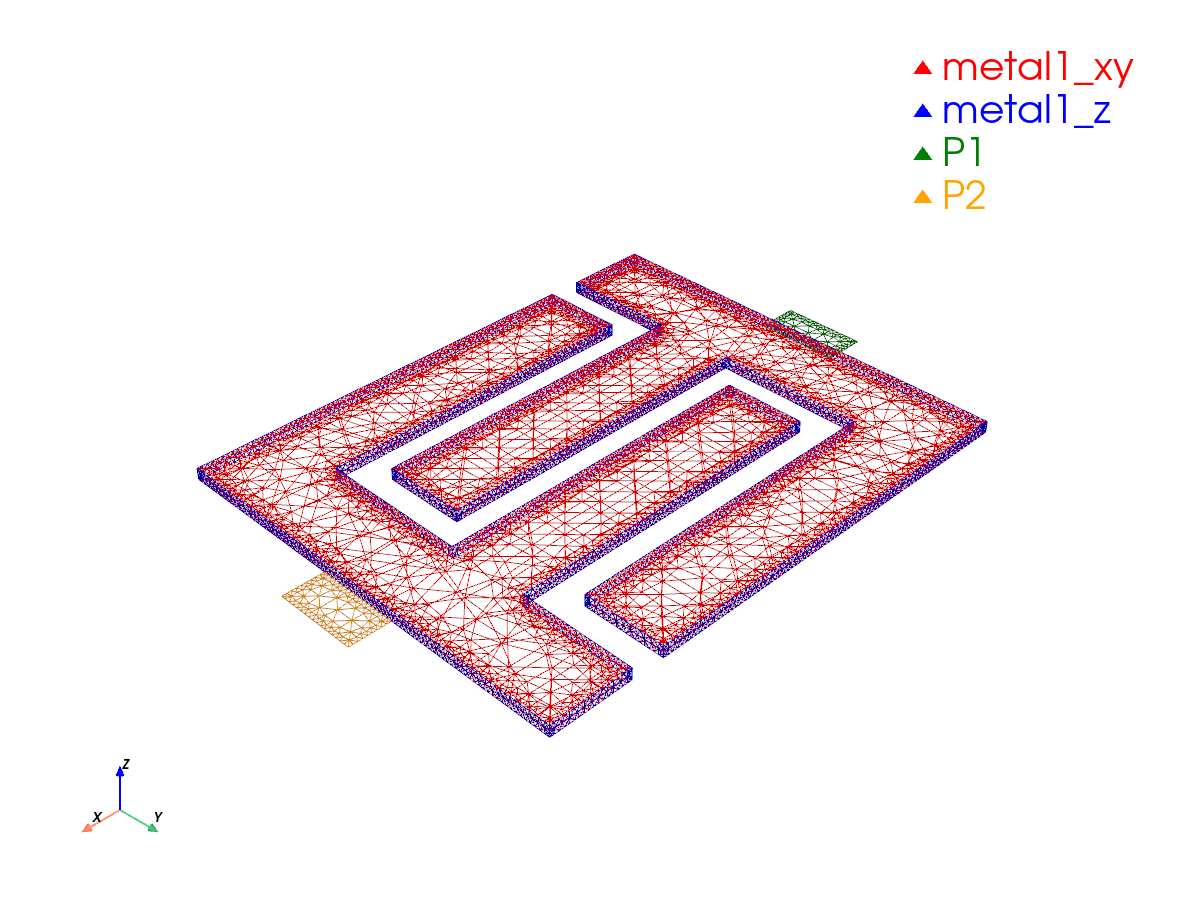

In [6]:
sim.plot_mesh(show_groups=["metal", "P"], interactive=False)

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

2026-04-01 00:04:28.351 (   2.813s) [    7B8E9B278080]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

2026-04-01 00:04:28.360 (   2.822s) [    7B8E9B278080]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

2026-04-01 00:04:28.392 (   2.854s) [    7B8E9B278080]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...


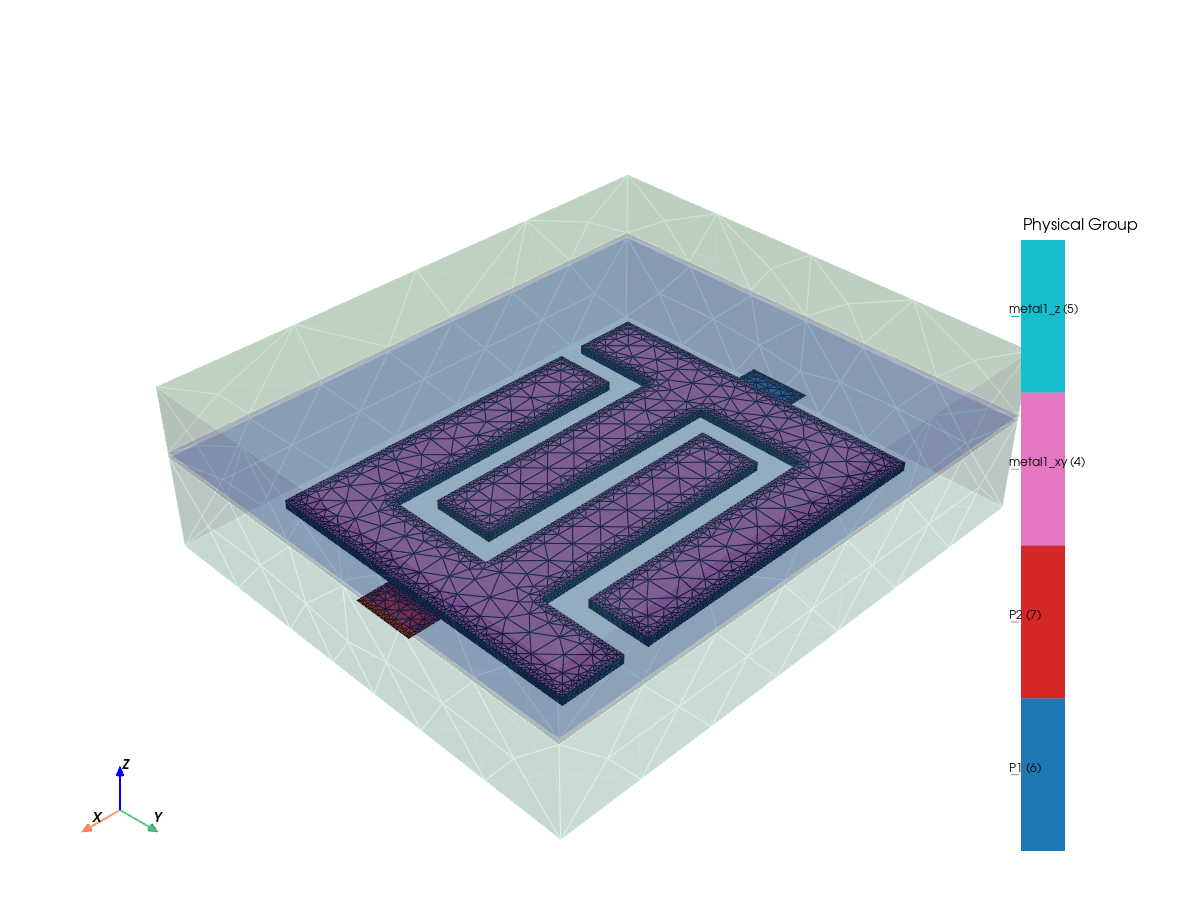

In [7]:
sim.plot_mesh(
    style="solid", interactive=False, 
    transparent_groups=["passive__None","air__None","air__passive","SiO2__None","SiO2__passive"],
)

In [8]:
results = sim.run(parent_dir="runs")

  palace-5d611dc5  completed  1m 03s
Extracting results.tar.gz...
Downloaded 11 files to runs/sim-data-palace-5d611dc5


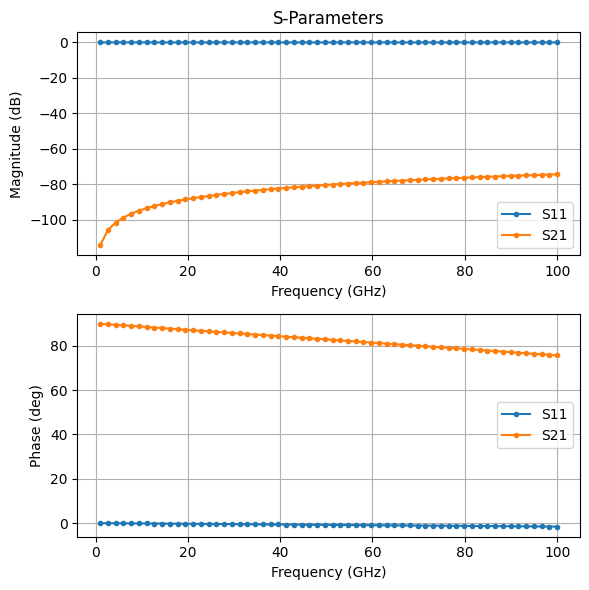

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv(results["port-S.csv"])
df.columns = df.columns.str.strip()  # Remove whitespace from column names

freq = df["f (GHz)"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 6))

# Magnitude plot
ax1.plot(freq, df["|S[1][1]| (dB)"], marker=".", label="S11")
ax1.plot(freq, df["|S[2][1]| (dB)"], marker=".", label="S21")
ax1.set_xlabel("Frequency (GHz)")
ax1.set_ylabel("Magnitude (dB)")
ax1.set_title("S-Parameters")
ax1.legend()
ax1.grid(True)

# Phase plot
ax2.plot(freq, df["arg(S[1][1]) (deg.)"], marker=".", label="S11")
ax2.plot(freq, df["arg(S[2][1]) (deg.)"], marker=".", label="S21")
ax2.set_xlabel("Frequency (GHz)")
ax2.set_ylabel("Phase (deg)")
ax2.legend()
ax2.grid(True)

plt.tight_layout()